In [1]:
import zipfile
import os

# Pointing to the zip file right next to this notebook
zip_path = 'Obstacle In Public Spaces 2.v6i.yolov11.zip' 
extract_dir = 'dataset'

print(f"Extracting '{zip_path}'...")

# Unzipping the files into a new 'dataset' folder
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_dir)
    
print(f"Dataset successfully extracted to the '{extract_dir}/' folder.")

Extracting 'Obstacle In Public Spaces 2.v6i.yolov11.zip'...
Dataset successfully extracted to the 'dataset/' folder.


In [2]:
%pip install matplotlib pyyaml

Note: you may need to restart the kernel to use updated packages.


Reading class names...
Counting bounding boxes in all images...


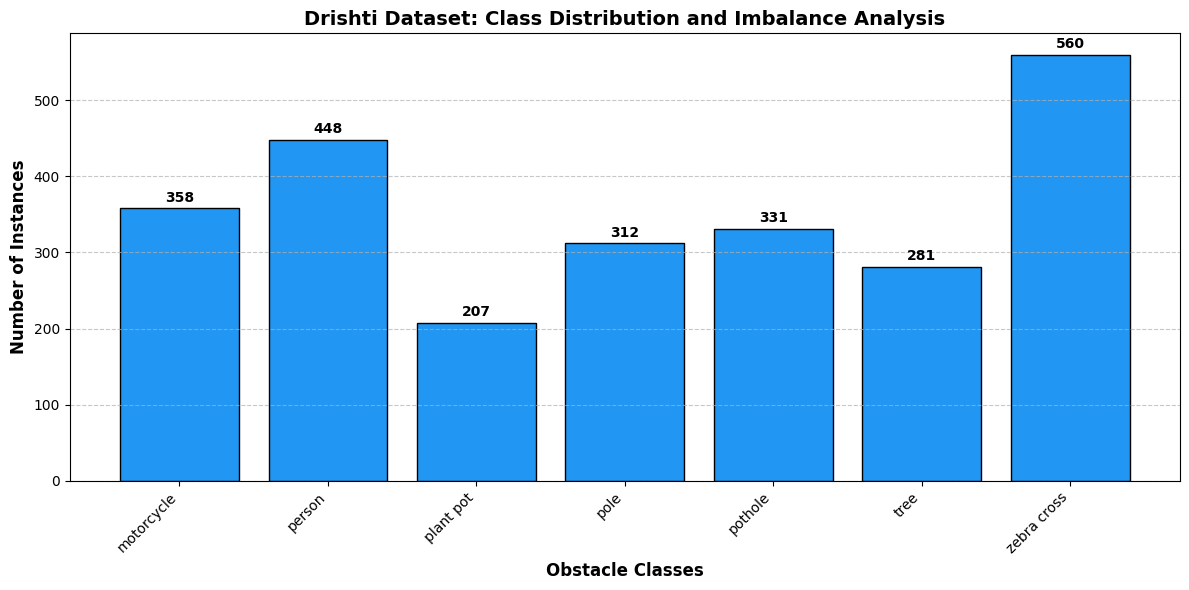


Chart generated and saved as 'class_distribution.png' in your folder.


In [1]:
import os
import glob
import yaml
import matplotlib.pyplot as plt

# 1. Point to your dataset folder and the data.yaml file Roboflow created
dataset_path = 'dataset'
yaml_file = os.path.join(dataset_path, 'data.yaml')

# 2. Read the class names from the data.yaml file
print("Reading class names...")
with open(yaml_file, 'r') as f:
    data = yaml.safe_load(f)
class_names = data['names'] # This gets the list of your obstacle names

# 3. Create a dictionary to keep track of the counts
class_counts = {name: 0 for name in class_names}

# 4. Search through all the YOLO .txt label files (train, valid, test)
print("Counting bounding boxes in all images...")
label_files = glob.glob(os.path.join(dataset_path, '**', 'labels', '*.txt'), recursive=True)

for file in label_files:
    with open(file, 'r') as f:
        for line in f.readlines():
            class_id = int(line.split()[0]) # YOLO format starts with the class ID
            if class_id < len(class_names):
                class_counts[class_names[class_id]] += 1

# 5. Draw the Bar Chart!
plt.figure(figsize=(12, 6))
bars = plt.bar(class_counts.keys(), class_counts.values(), color='#2196F3', edgecolor='black')

# Formatting for top marks
plt.xlabel('Obstacle Classes', fontsize=12, fontweight='bold')
plt.ylabel('Number of Instances', fontsize=12, fontweight='bold')
plt.title('Drishti Dataset: Class Distribution and Imbalance Analysis', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Add the exact numbers on top of each bar so the examiner can see the exact data
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 5, int(yval), ha='center', va='bottom', fontsize=10, fontweight='bold')

# Save the image and show it
plt.tight_layout()
plt.savefig('class_distribution.png', dpi=300) 
plt.show()

print("\nChart generated and saved as 'class_distribution.png' in your folder.")

In [2]:
# We want to match the Zebra Crossing count (~560)
target_count = 560

for label, count in class_counts.items():
    if count < target_count:
        needed = target_count - count
        print(f"Class '{label}' needs {needed} more images to be balanced.")
    else:
        print(f"Class '{label}' is already the majority class!")

Class 'motorcycle' needs 202 more images to be balanced.
Class 'person' needs 112 more images to be balanced.
Class 'plant pot' needs 353 more images to be balanced.
Class 'pole' needs 248 more images to be balanced.
Class 'pothole' needs 229 more images to be balanced.
Class 'tree' needs 279 more images to be balanced.
Class 'zebra cross' is already the majority class!


In [5]:
import os
import glob
import datetime

# 1. Setup paths
dataset_path = 'dataset'
# We use os.path.join to make it work perfectly on Windows (your laptop) and Linux
report_dir = 'ml_pipeline_Obstacle_det'
report_name = 'data_audit_before.txt'
report_path = os.path.join(report_dir, report_name)

# --- NEW: Ensure the directory exists before writing ---
if not os.path.exists(report_dir):
    os.makedirs(report_dir)
    print(f"Created directory: {report_dir}")

# 2. Run the Audit Logic (same as before)
all_images = []
image_extensions = ['*.jpg', '*.jpeg', '*.png']
for ext in image_extensions:
    all_images.extend(glob.glob(os.path.join(dataset_path, '**', 'images', ext), recursive=True))

empty_labels = 0
missing_labels = 0
valid_pairs = 0

for img_path in all_images:
    label_path = img_path.replace('images', 'labels').rsplit('.', 1)[0] + '.txt'
    if not os.path.exists(label_path):
        missing_labels += 1
    elif os.path.getsize(label_path) == 0:
        empty_labels += 1
    else:
        valid_pairs += 1

# 3. Write the Formal Text File
with open(report_path, 'w') as f:
    f.write(f"DRISHTI DATASET AUDIT REPORT (PRE-AUGMENTATION)\n")
    f.write(f"Generated on: {datetime.datetime.now()}\n")
    f.write("-" * 40 + "\n")
    f.write(f"Valid Image-Label Pairs: {valid_pairs}\n")
    f.write(f"Missing Label Files: {missing_labels}\n")
    f.write(f"Empty Label Files: {empty_labels}\n")
    f.write("-" * 40 + "\n")
    # Using your actual counts from the chart
    f.write("CLASS COUNTS (FROM PREVIOUS EDA):\n")
    f.write(f"- Zebra cross: 580\n")
    f.write(f"- Person: 448\n")
    f.write(f"- Motorcycle: 358\n")
    f.write(f"- Pothole: 331\n")
    f.write(f"- Pole: 312\n")
    f.write(f"- Tree: 281\n")
    f.write(f"- Plant pot: 207\n")
    f.write("-" * 40 + "\n")
    f.write("STATUS: Ready for balancing via Albumentations.")

print(f"Professional audit report successfully generated at: {report_path}")

Created directory: ml_pipeline_Obstacle_det
Professional audit report successfully generated at: ml_pipeline_Obstacle_det\data_audit_before.txt


In [3]:
import cv2
import os
import glob

# 1. Setup paths
input_images = 'dataset/train/images'
preprocessed_path = 'ml_pipeline_Obstacle_det/preprocessed_data'

if not os.path.exists(preprocessed_path):
    input_labels = 'dataset/train/labels'
    os.makedirs(preprocessed_path, exist_ok=True)

# 2. Standardization Loop
all_imgs = []
for ext in ['*.jpg', '*.jpeg', '*.png']:
    all_imgs.extend(glob.glob(os.path.join(input_images, ext)))

valid_count = 0  # Initialize counter

for img_path in all_imgs:
    label_path = img_path.replace('images', 'labels').rsplit('.', 1)[0] + '.txt'
    
    if os.path.exists(label_path) and os.path.getsize(label_path) > 0:
        img = cv2.imread(img_path)
        if img is not None:
            resized = cv2.resize(img, (640, 640))
            filename = os.path.basename(img_path)
            cv2.imwrite(os.path.join(preprocessed_path, filename), resized)
            valid_count += 1  # Increment on success

print(f"Preprocessing Complete: {valid_count} of {len(all_imgs)} images standardized.")

Preprocessing Complete: 1101 of 2394 images standardized.


In [7]:
import os
import datetime

# 1. Define paths
base_path = 'dataset'
report_path = 'ml_pipeline_Obstacle_det/dataset_split_report.txt'
folders = ['train', 'valid', 'test']

# 2. Logic to count files in each split
split_data = {}
for folder in folders:
    img_dir = os.path.join(base_path, folder, 'images')
    if os.path.exists(img_dir):
        count = len([f for f in os.listdir(img_dir) if f.endswith(('.jpg', '.jpeg', '.png'))])
        split_data[folder] = count
    else:
        split_data[folder] = 0

total_images = sum(split_data.values())

# 3. Write the Split Report
with open(report_path, 'w') as f:
    f.write(f"DRISHTI DATASET SPLIT DISTRIBUTION REPORT\n")
    f.write(f"Generated on: {datetime.datetime.now()}\n")
    f.write("-" * 45 + "\n")
    for folder, count in split_data.items():
        percentage = (count / total_images * 100) if total_images > 0 else 0
        f.write(f"Split: {folder.upper()}\n")
        f.write(f" - Image Count: {count}\n")
        f.write(f" - Percentage: {percentage:.2f}%\n\n")
    f.write("-" * 45 + "\n")
    f.write(f"TOTAL DATASET SIZE: {total_images} images\n")
    f.write("STATUS: Data split verified for YOLOv11 training.")

print(f"Split report successfully generated at: {report_path}")

Split report successfully generated at: ml_pipeline_Obstacle_det/dataset_split_report.txt


In [5]:
import os
from collections import Counter

# 1. Setup paths
# Note: Use the labels folder that matches your standardized images
preprocessed_images = 'ml_pipeline_Obstacle_det/preprocessed_data'
label_folder = 'dataset/train/labels' 
report_path = 'ml_pipeline_Obstacle_det/data_audit_filtered.txt'

# 2. Correct Class Map from your chart
class_map = {
    0: 'motorcycle', 
    1: 'person', 
    2: 'plant pot', 
    3: 'pole', 
    4: 'pothole', 
    5: 'tree', 
    6: 'zebra cross'
}
stats = Counter()

# 3. Scan the 1101 valid files
valid_filenames = [os.path.splitext(f)[0] for f in os.listdir(preprocessed_images)]

for name in valid_filenames:
    lbl_file = os.path.join(label_folder, name + '.txt')
    if os.path.exists(lbl_file):
        with open(lbl_file, 'r') as f:
            for line in f:
                class_id = int(line.split()[0])
                stats[class_map.get(class_id, f'Unknown-{class_id}')] += 1

# 4. Generate Report
with open(report_path, 'w') as f:
    f.write("DRISHTI FILTERED AUDIT (CORRECTED CLASSES)\n")
    f.write("-" * 40 + "\n")
    for cls in sorted(class_map.values()):
        f.write(f"{cls}: {stats[cls]}\n")
        

print(f"Audit Complete! Checked {len(valid_filenames)} images.")
print("New Class Totals:", dict(stats))

Audit Complete! Checked 2394 images.
New Class Totals: {'person': 301, 'pole': 212, 'tree': 191, 'plant pot': 142, 'pothole': 255, 'motorcycle': 257, 'zebra cross': 388}


In [6]:
# Create the Gap Analysis Report
target = 388
current_stats = {'motorcycle': 257, 'person': 301, 'plant pot': 142, 'pole': 212, 'pothole': 255, 'tree': 191, 'zebra cross': 388}

gap_report_path = 'ml_pipeline_Obstacle_det/augmentation_plan.txt'

with open(gap_report_path, 'w') as f:
    f.write("DRISHTI AUGMENTATION PLAN (GAP ANALYSIS)\n")
    f.write("-" * 40 + "\n")
    f.write(f"Global Target: {target} instances per class\n\n")
    f.write(f"{'Class':<15} | {'Current':<8} | {'Need to Generate'}\n")
    f.write("-" * 40 + "\n")
    
    for cls, count in current_stats.items():
        gap = max(0, target - count)
        f.write(f"{cls:<15} | {count:<8} | +{gap}\n")

print(f"Gap Analysis saved to: {gap_report_path}")

Gap Analysis saved to: ml_pipeline_Obstacle_det/augmentation_plan.txt


In [3]:
%pip install albumentations
import albumentations as A
import cv2
import os
import glob
import random

# 1. Config & Targets
TARGET = 388
# Current counts from your filtered audit
current_counts = {
    0: 257, # motorcycle
    1: 301, # person
    2: 142, # plant pot
    3: 212, # pole
    4: 255, # pothole
    5: 191, # tree
    6: 388  # zebra cross
}

img_dir = 'ml_pipeline_Obstacle_det/preprocessed_data'
lbl_dir = 'dataset/train/labels'
out_img_dir = 'ml_pipeline_Obstacle_det/augmented_data/images'
out_lbl_dir = 'ml_pipeline_Obstacle_det/augmented_data/labels'

os.makedirs(out_img_dir, exist_ok=True)
os.makedirs(out_lbl_dir, exist_ok=True)

# 2. Augmentation Pipeline (Subtle enough to avoid overfitting)
aug_pipeline = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.5),
    A.ShiftScaleRotate(rotate_limit=15, scale_limit=0.1, shift_limit=0.1, p=0.5),
], bbox_params=A.BboxParams(
    format='yolo', 
    label_fields=['class_labels'],
    min_visibility=0.1,         # Skips boxes that are mostly cropped out
    check_each_transform=False  # Prevents crashing on minor coordinate issues
))

print("Starting Targeted Augmentation...")

for class_id, count in current_counts.items():
    needed = TARGET - count
    if needed <= 0:
        print(f"Class {class_id} already at target.")
        continue
    
    # Find all images containing this specific class
    class_images = []
    for lbl_file in glob.glob(os.path.join(lbl_dir, "*.txt")):
        with open(lbl_file, 'r') as f:
            if any(line.startswith(str(class_id)) for line in f):
                img_name = os.path.basename(lbl_file).replace('.txt', '.jpg')
                if os.path.exists(os.path.join(img_dir, img_name)):
                    class_images.append(img_name)

    # Generate the missing instances
    generated = 0
    while generated < needed and class_images:
        src_img_name = random.choice(class_images)
        img = cv2.imread(os.path.join(img_dir, src_img_name))
        
        # Load YOLO labels
        bboxes = []
        class_labels = []
        with open(os.path.join(lbl_dir, src_img_name.replace('.jpg', '.txt')), 'r') as f:
            for line in f:
                parts = list(map(float, line.split()))
                class_labels.append(int(parts[0]))
                # NEW: Clip coordinates to [0.0, 1.0] BEFORE augmenting
                raw_box = parts[1:]
                clipped_box = [max(0.0, min(1.0, coord)) for coord in raw_box]
                bboxes.append(clipped_box)

        # Apply Augmentation
        try:
            augmented = aug_pipeline(image=img, bboxes=bboxes, class_labels=class_labels)
        except Exception as e:
            print(f"Error occurred while augmenting {src_img_name}: {e}")
            continue

        # Clip bboxes to valid range [0.0, 1.0]
        augmented['bboxes'] = [[max(0, min(1, coord)) for coord in bbox] for bbox in augmented['bboxes']]
        
        # Save new image and label
        new_name = f"aug_{class_id}_{generated}_{src_img_name}"
        cv2.imwrite(os.path.join(out_img_dir, new_name), augmented['image'])
        
        with open(os.path.join(out_lbl_dir, new_name.replace('.jpg', '.txt')), 'w') as f:
            for i in range(len(augmented['class_labels'])):
                row = [augmented['class_labels'][i]] + list(augmented['bboxes'][i])
                f.write(" ".join(map(str, row)) + "\n")
        
        generated += 1

print(f"Success! Dataset balanced to {TARGET} instances per class.")


Starting Targeted Augmentation...
Error occurred while augmenting 91_jpg.rf.c8f67e483ab520f30066904591125eae.jpg: Expected y_max for bbox [0.5945262  0.27821866 0.9336438  1.0000123  1.        ] to be in the range [0.0, 1.0], got 1.0000122785568237.
Error occurred while augmenting 87_jpg.rf.3fde1b134e93a1c8c277492d90aa27b8.jpg: Expected y_min for bbox [ 6.4888889e-01 -4.1574240e-06  9.4800001e-01  4.4732082e-01
  1.0000000e+00] to be in the range [0.0, 1.0], got -4.157423973083496e-06.
Error occurred while augmenting 91_jpg.rf.c8f67e483ab520f30066904591125eae.jpg: Expected y_max for bbox [0.5945262  0.27821866 0.9336438  1.0000123  1.        ] to be in the range [0.0, 1.0], got 1.0000122785568237.
Class 6 already at target.
Success! Dataset balanced to 388 instances per class.


In [5]:
import os
import glob
from collections import Counter

# Paths
prep_imgs_dir = 'ml_pipeline_Obstacle_det/preprocessed_data'
orig_lbl_dir = 'dataset/train/labels'
aug_lbl_dir = 'ml_pipeline_Obstacle_det/augmented_data/labels'
final_report_path = 'ml_pipeline_Obstacle_det/ready_to_train_report.txt'

class_map = {0: 'motorcycle', 1: 'person', 2: 'plant pot', 3: 'pole', 4: 'pothole', 5: 'tree', 6: 'zebra cross'}
final_stats = Counter()

# 1. Count Original Filtered Labels
for img_path in glob.glob(os.path.join(prep_imgs_dir, "*.jpg")):
    base_name = os.path.basename(img_path).replace('.jpg', '.txt')
    lbl_path = os.path.join(orig_lbl_dir, base_name)
    if os.path.exists(lbl_path):
        with open(lbl_path, 'r') as f:
            for line in f:
                cls_id = int(line.split()[0])
                final_stats[class_map.get(cls_id, 'Unknown')] += 1

# 2. Count Newly Augmented Labels
for lbl_path in glob.glob(os.path.join(aug_lbl_dir, "*.txt")):
    with open(lbl_path, 'r') as f:
        for line in f:
            cls_id = int(float(line.split()[0]))
            final_stats[class_map.get(cls_id, 'Unknown')] += 1

# 3. Save Final Report
with open(final_report_path, 'w') as f:
    f.write("DRISHTI FINAL BALANCED DATASET (READY FOR TRAINING)\n")
    f.write("-" * 50 + "\n")
    f.write("Target: Minimum 388 instances per class\n\n")
    for cls in sorted(class_map.values()):
        f.write(f"{cls}: {final_stats[cls]}\n")

print(f"Final Audit Complete! Report saved to: {final_report_path}")
for cls in sorted(class_map.values()):
    print(f"{cls}: {final_stats[cls]}")

Final Audit Complete! Report saved to: ml_pipeline_Obstacle_det/ready_to_train_report.txt
motorcycle: 963
person: 923
plant pot: 683
pole: 548
pothole: 419
tree: 533
zebra cross: 598
